# NYISO Solar Forecasting: Error Analysis

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [47]:
%matplotlib inline

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from solar_forecast.config import (
    MODEL_READY_OUT,
    FIGURES_ROOT,
    MODEL_ROOT,
    TARGET   as target,
    TS_COL   as ts_col,
    ZONE_COL as zone_col,
)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

## Load Table and Saved Files

In [48]:
df_model = pd.read_csv(MODEL_READY_OUT, low_memory=False)

df_model.columns = (
    df_model.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_model[ts_col]       = pd.to_datetime(df_model[ts_col], utc=True, errors="coerce")
df_model["time_local"] = df_model[ts_col].dt.tz_convert("America/New_York")

df_model["hour_local"]      = df_model["time_local"].dt.hour
df_model["month_local"]     = df_model["time_local"].dt.month
df_model["dayofyear_local"] = df_model["time_local"].dt.dayofyear
df_model["is_daylight"]     = (df_model["shortwave_radiation"] > 0).astype(int)

required_cols = [
    ts_col,
    "time_local",
    zone_col,
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    target,
]

missing_required = [c for c in required_cols if c not in df_model.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

In [52]:
test_idx = (
    df_model["dataset_split"].eq("test")
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

test_df  = df_model.loc[test_idx].copy()
day_test = test_df["is_daylight"] == 1

valid_results = pd.read_csv(MODEL_ROOT / "tuned_validation_results.csv")
test_results = pd.read_csv(MODEL_ROOT / "tuned_test_results.csv")
feature_importance = pd.read_csv(MODEL_ROOT / "tuned_feature_importance.csv")
best_preds = pd.read_csv(MODEL_ROOT / "tuned_best_model_test_predictions.csv")

best_preds[ts_col] = pd.to_datetime(best_preds[ts_col], utc=True, errors="coerce")
best_preds["time_local"] = pd.to_datetime(best_preds["time_local"], errors="coerce")

best_model      = valid_results.iloc[0]["Model"]
best_test_model = test_results.iloc[0]["Model"]

print("Validation-Selected Model:", best_model)
print("Best Test Model:",           best_test_model)

Validation-Selected Model: Month-Hour Residual Climatology
Best Test Model: Random Forest Residual Model (Tuned)


In [53]:
print("\nValidation Results")
print(". . .")
print(valid_results)


Validation Results
. . .
                                  Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0       Month-Hour Residual Climatology  103.229828  205.806504    116.339272     220.914808                  0.639403   
1        XGBoost Residual Model (Tuned)  103.201456  205.927479    116.751501     221.943812                  0.667776   
2       CatBoost Residual Model (Tuned)  103.101085  206.805896    116.682043     223.372717                  0.768147   
3       LightGBM Residual Model (Tuned)  103.696182  207.319515    117.586124     224.388624                  0.173049   
4                        NYISO Baseline  103.869232  209.018702    117.992367     226.722355                  0.000000   
5  Random Forest Residual Model (Tuned)  106.710330  208.923936    120.267034     223.938748                 -2.841099   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  Selection_Score  


In [54]:
print("\nTest Results")
print(". . .")
print(test_results)


Test Results
. . .
                                  Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0  Random Forest Residual Model (Tuned)   97.415299  195.926930    112.090311     212.690499                  9.535864   
1        XGBoost Residual Model (Tuned)   99.737756  198.537188    114.413713     215.223625                  7.213406   
2       LightGBM Residual Model (Tuned)  100.798245  200.234745    115.410710     216.915672                  6.152918   
3       CatBoost Residual Model (Tuned)  101.573293  200.595075    117.152664     217.991332                  5.377870   
4       Month-Hour Residual Climatology  101.137302  200.785806    117.178717     219.257419                  5.813861   
5                        NYISO Baseline  106.951163  207.750489    123.785560     226.721206                  0.000000   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  Selection_Score  
0     

In [55]:
context_cols = [
    ts_col,
    "time_local",
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
    target,
    "shortwave_radiation",
    "cloud_cover",
    "temperature_2m",
    "windspeed_10m",
    "surface_pressure",
    "forecast_diff_1",
    "shortwave_diff_1",
    "shortwave_ramp_abs",
    "is_morning_ramp",
    "is_midday",
]

non_key_cols = [c for c in context_cols if c != ts_col]

best_preds[ts_col] = pd.to_datetime(best_preds[ts_col], utc=True, errors="coerce")
test_df[ts_col]    = pd.to_datetime(test_df[ts_col],    utc=True, errors="coerce")

In [56]:
analysis_df = (
    best_preds
    .drop(columns=[c for c in non_key_cols if c in best_preds.columns], errors="ignore")
    .merge(test_df[context_cols], on=ts_col, how="left", validate="one_to_one")
    .copy()
)

analysis_df["baseline_sq_error"]  = analysis_df["baseline_error_mw"] ** 2
analysis_df["model_sq_error"]     = analysis_df["model_error_mw"] ** 2
analysis_df["error_reduction"]    = analysis_df["baseline_abs_error"] - analysis_df["model_abs_error"]
analysis_df["sq_error_reduction"] = analysis_df["baseline_sq_error"]  - analysis_df["model_sq_error"]
analysis_df["improved_flag"]      = (analysis_df["error_reduction"] > 0).astype(int)
analysis_df["worsened_flag"]      = (analysis_df["error_reduction"] < 0).astype(int)
analysis_df["baseline_under"]     = (analysis_df["baseline_error_mw"] > 0).astype(int)
analysis_df["model_under"]        = (analysis_df["model_error_mw"]    > 0).astype(int)
analysis_df["error_change_pct"]   = np.where(
    analysis_df["baseline_abs_error"] > 0,
    100 * analysis_df["error_reduction"] / analysis_df["baseline_abs_error"],
    np.nan,
)

print("Analysis Shape:", analysis_df.shape)
print("\nMissing Core Regime Fields:")
print(". . .")
print(analysis_df[["is_daylight", "is_morning_ramp", "is_midday"]].isna().sum())

Analysis Shape: (10529, 34)

Missing Core Regime Fields:
. . .
is_daylight        0
is_morning_ramp    0
is_midday          0
dtype: int64


## Summary Helper Function

In [57]:
def summarize_errors(df):
    return pd.Series({
        "n_obs":          len(df),
        "baseline_mae":   df["baseline_abs_error"].mean(),
        "model_mae":      df["model_abs_error"].mean(),
        "baseline_rmse":  np.sqrt(df["baseline_sq_error"].mean()),
        "model_rmse":     np.sqrt(df["model_sq_error"].mean()),
        "baseline_bias":  df["baseline_error_mw"].mean(),
        "model_bias":     df["model_error_mw"].mean(),
        "improved_share": df["improved_flag"].mean(),
        "worsened_share": df["worsened_flag"].mean(),
    })


def add_reduction_cols(df):
    df["mae_reduction"]  = df["baseline_mae"]  - df["model_mae"]
    df["rmse_reduction"] = df["baseline_rmse"] - df["model_rmse"]
    df["mae_reduction_pct"]  = 100 * df["mae_reduction"]  / df["baseline_mae"]
    df["rmse_reduction_pct"] = 100 * df["rmse_reduction"] / df["baseline_rmse"]
    return df

## Error Summary

In [58]:
resid_summary = pd.DataFrame({
    "metric": [
        "baseline_error_mean",
        "baseline_error_std",
        "model_error_mean",
        "model_error_std",
        "baseline_abs_error_mean",
        "model_abs_error_mean",
        "baseline_rmse",
        "model_rmse",
        "share_rows_improved",
        "share_rows_worsened",
        "baseline_under_share",
        "model_under_share",
    ],
    "value": [
        analysis_df["baseline_error_mw"].mean(),
        analysis_df["baseline_error_mw"].std(),
        analysis_df["model_error_mw"].mean(),
        analysis_df["model_error_mw"].std(),
        analysis_df["baseline_abs_error"].mean(),
        analysis_df["model_abs_error"].mean(),
        np.sqrt(analysis_df["baseline_sq_error"].mean()),
        np.sqrt(analysis_df["model_sq_error"].mean()),
        analysis_df["improved_flag"].mean(),
        analysis_df["worsened_flag"].mean(),
        analysis_df["baseline_under"].mean(),
        analysis_df["model_under"].mean(),
    ],
})

resid_summary

,metric,value
0,baseline_error_mean,-14.922480
1,baseline_error_std,207.223704
2,model_error_mean,-12.507294
3,model_error_std,200.405394
4,baseline_abs_error_mean,106.951163
5,model_abs_error_mean,101.137302
6,baseline_rmse,207.750489
7,model_rmse,200.785806
8,share_rows_improved,0.354830
9,share_rows_worsened,0.243993


In [59]:
overall_summary = summarize_errors(analysis_df).to_frame().T
overall_summary = add_reduction_cols(overall_summary)

overall_summary

,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction,mae_reduction_pct,rmse_reduction_pct
0,10529.0,106.951163,101.137302,207.750489,200.785806,-14.92248,-12.507294,0.35483,0.243993,5.813861,6.964683,5.435996,3.352427


## Diagnostics by Regime

In [60]:
regime_summary = (
    analysis_df
    .assign(regime=np.where(analysis_df["is_daylight"] == 1, "Daylight", "Non-Daylight"))
    .groupby("regime")
    .apply(summarize_errors)
    .reset_index()
)

regime_summary = add_reduction_cols(regime_summary)

regime_summary

,regime,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction,mae_reduction_pct,rmse_reduction_pct
0,Daylight,5791.0,123.785560,117.178717,226.721206,219.257419,-18.420722,-14.791874,0.370057,0.274909,6.606843,7.463787,5.337330,3.292055
1,Non-Daylight,4738.0,86.375393,81.530751,181.896189,175.589541,-10.646769,-9.714975,0.336218,0.206205,4.844641,6.306648,5.608821,3.467169


In [61]:
ramp_summary = (
    analysis_df
    .assign(regime=np.where(analysis_df["is_morning_ramp"] == 1, "Morning Ramp", "Non-Morning Ramp"))
    .groupby("regime")
    .apply(summarize_errors)
    .reset_index()
)

ramp_summary = add_reduction_cols(ramp_summary)

ramp_summary

,regime,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction,mae_reduction_pct,rmse_reduction_pct
0,Morning Ramp,1756.0,276.965262,273.427683,364.705076,358.042934,20.726139,-8.211663,0.544419,0.455581,3.537579,6.662143,1.277265,1.826721
1,Non-Morning Ramp,8773.0,72.921212,66.651731,158.669536,150.747986,-22.057892,-13.367105,0.316881,0.201641,6.269480,7.921550,8.597609,4.992484


In [62]:
midday_summary = (
    analysis_df
    .assign(regime=np.where(analysis_df["is_midday"] == 1, "Midday", "Non-Midday"))
    .groupby("regime")
    .apply(summarize_errors)
    .reset_index()
)

midday_summary = add_reduction_cols(midday_summary)

midday_summary

,regime,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction,mae_reduction_pct,rmse_reduction_pct
0,Midday,2194.0,162.257338,148.302993,245.897168,232.881696,-56.101367,-32.377746,0.526892,0.369644,13.954345,13.015472,8.600132,5.293055
1,Non-Midday,8335.0,92.393064,88.722001,196.481745,191.444751,-4.083070,-7.276847,0.309538,0.210918,3.671063,5.036994,3.973310,2.563594


## Diagnostics by Temporal Features

In [63]:
hourly_errors = (
    analysis_df.loc[analysis_df["is_daylight"] == 1]
    .groupby("hour_local")
    .apply(summarize_errors)
    .reset_index()
)
hourly_errors["mae_reduction"]  = hourly_errors["baseline_mae"]  - hourly_errors["model_mae"]
hourly_errors["rmse_reduction"] = hourly_errors["baseline_rmse"] - hourly_errors["model_rmse"]

hourly_errors

,hour_local,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction
0,6,100.0,267.440600,268.839591,359.235038,358.732378,17.903200,-43.278575,0.480000,0.520000,-1.398991,0.502660
1,7,275.0,271.328291,272.386558,354.398712,351.589470,36.187491,-4.698711,0.494545,0.505455,-1.058267,2.809242
2,8,439.0,288.650547,285.891428,377.155744,369.854821,30.122210,-1.144091,0.537585,0.462415,2.759119,7.300924
3,9,439.0,258.808793,255.745332,344.842812,339.661195,16.581503,-7.658120,0.544419,0.455581,3.063461,5.181617
4,10,439.0,225.555513,222.107590,316.307568,312.500300,-12.451412,-20.961845,0.551253,0.448747,3.447922,3.807268
5,11,439.0,196.335535,190.978440,288.889218,284.145493,-48.280091,-36.826237,0.605923,0.394077,5.357095,4.743726
6,12,439.0,162.965763,151.248811,243.852028,230.035689,-70.614374,-38.651058,0.505695,0.437358,11.716952,13.816338
7,13,439.0,134.744670,110.731692,195.194127,165.331357,-81.844897,-38.504308,0.476082,0.325740,24.012977,29.862770
8,14,438.0,91.524087,66.261550,145.483842,111.481915,-67.341667,-26.932877,0.495434,0.242009,25.262536,34.001927
9,15,438.0,39.480434,27.849760,80.871638,64.295228,-32.701484,-10.796642,0.470320,0.223744,11.630674,16.576410


In [64]:
monthly_errors = (
    analysis_df
    .groupby("month_local")
    .apply(summarize_errors)
    .reset_index()
)

monthly_errors["mae_reduction"]  = monthly_errors["baseline_mae"]  - monthly_errors["model_mae"]
monthly_errors["rmse_reduction"] = monthly_errors["baseline_rmse"] - monthly_errors["model_rmse"]

monthly_errors

,month_local,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction
0,1,744.0,90.022392,88.774595,211.440929,209.695279,22.543495,18.903098,0.258065,0.200269,1.247797,1.745651
1,2,672.0,99.201726,89.942882,207.269024,188.771814,63.368363,36.516589,0.331845,0.209821,9.258844,18.497210
2,3,742.0,132.253248,127.894423,273.475757,263.256851,40.861388,5.722867,0.301887,0.323450,4.358825,10.218907
3,4,720.0,108.603139,109.088038,203.792935,200.431455,6.195889,-8.284430,0.280556,0.344444,-0.484899,3.361481
4,5,714.0,128.481835,128.548019,240.350651,238.986473,15.765700,-12.495533,0.303922,0.355742,-0.066184,1.364178
5,6,724.0,110.059751,111.144084,212.596970,211.780341,-6.977624,-3.553292,0.305249,0.399171,-1.084333,0.816629
6,7,1488.0,117.917507,116.248533,210.342850,209.831396,-25.770827,-29.080461,0.362903,0.303763,1.668973,0.511454
7,8,1488.0,110.636028,98.846314,201.017856,191.761293,-45.034227,-21.505264,0.470430,0.195565,11.789715,9.256563
8,9,1148.0,109.979556,96.213777,192.824382,179.343397,-45.998650,-12.355150,0.411150,0.184669,13.765779,13.480985
9,10,696.0,97.709497,84.050294,171.340070,155.068142,-63.242486,-43.975075,0.443966,0.103448,13.659203,16.271928


## Diagonistics by Weather Features

In [65]:
weather_vars = [
    "forecast_mw",
    "shortwave_radiation",
    "cloud_cover",
    "temperature_2m",
    "shortwave_ramp_abs",
]

for col in weather_vars:
    analysis_df[f"{col}_bin"] = pd.qcut(analysis_df[col], q=5, duplicates="drop")

weather_frames = []

for col in weather_vars:
    tmp = (
        analysis_df
        .groupby(f"{col}_bin", observed=False)
        .apply(summarize_errors)
        .reset_index()
    )
    tmp["variable"]       = col
    tmp["bin"]            = tmp[f"{col}_bin"].astype(str)
    tmp["mae_reduction"]  = tmp["baseline_mae"]  - tmp["model_mae"]
    tmp["rmse_reduction"] = tmp["baseline_rmse"] - tmp["model_rmse"]

    weather_frames.append(tmp[[
        "variable", "bin", "n_obs",
        "baseline_mae", "model_mae",
        "baseline_rmse", "model_rmse",
        "baseline_bias", "model_bias",
        "improved_share", "worsened_share",
        "mae_reduction", "rmse_reduction",
    ]])

weather_summary = pd.concat(weather_frames, ignore_index=True)

weather_summary

,variable,bin,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction,rmse_reduction
0,forecast_mw,"(-0.001, 555.192]",6317.0,16.844385,13.279881,48.443784,41.353922,-7.678246,-3.069139,0.207535,0.123793,3.564504,7.089862
1,forecast_mw,"(555.192, 1902.24]",2106.0,238.556406,225.245638,318.354031,304.828866,-60.486681,-51.359371,0.620133,0.379867,13.310767,13.525165
2,forecast_mw,"(1902.24, 5192.28]",2106.0,245.623466,240.559509,327.707581,321.722380,8.912460,-1.965199,0.531339,0.468661,5.063958,5.985201
3,shortwave_radiation,"(-0.001, 97.0]",6331.0,98.175092,94.426036,200.597800,195.617590,-7.681578,-11.183739,0.319223,0.214184,3.749056,4.980210
4,shortwave_radiation,"(97.0, 381.0]",2095.0,109.024210,105.500132,219.508253,212.921807,-3.462864,-7.153463,0.304535,0.270644,3.524078,6.586446
5,shortwave_radiation,"(381.0, 965.0]",2103.0,131.306020,116.995073,216.676458,203.668381,-48.136957,-21.825266,0.512126,0.307180,14.310947,13.008077
6,cloud_cover,"(-0.001, 7.0]",2143.0,94.500882,87.987765,176.642437,170.265018,-25.189085,-16.975306,0.383574,0.216986,6.513117,6.377419
7,cloud_cover,"(7.0, 64.0]",2084.0,105.178724,96.969106,199.262367,190.110319,-10.238580,-1.482436,0.372841,0.232726,8.209618,9.152048
8,cloud_cover,"(64.0, 100.0]",6302.0,111.771016,106.987187,219.929422,213.414855,-12.980225,-14.633738,0.339099,0.256903,4.783828,6.514567
9,temperature_2m,"(-23.801000000000002, -0.8]",2124.0,102.356474,95.271644,218.042610,205.933372,21.067604,11.072429,0.315913,0.209040,7.084830,12.109238


## Distribution and Case-Based Diagnostics

In [67]:
error_quantiles = pd.DataFrame({
    "metric": [
        "baseline_p50", "model_p50",
        "baseline_p90", "model_p90",
        "baseline_p95", "model_p95",
        "baseline_p99", "model_p99",
    ],
    "value": [
        analysis_df["baseline_abs_error"].quantile(0.50),
        analysis_df["model_abs_error"].quantile(0.50),
        analysis_df["baseline_abs_error"].quantile(0.90),
        analysis_df["model_abs_error"].quantile(0.90),
        analysis_df["baseline_abs_error"].quantile(0.95),
        analysis_df["model_abs_error"].quantile(0.95),
        analysis_df["baseline_abs_error"].quantile(0.99),
        analysis_df["model_abs_error"].quantile(0.99),
    ],
})

error_quantiles

,metric,value
0,baseline_p50,13.530000
1,model_p50,10.099913
2,baseline_p90,345.000000
3,model_p90,333.000103
4,baseline_p95,470.268000
5,model_p95,463.145774
6,baseline_p99,802.304000
7,model_p99,787.278375


In [68]:
case_cols = [
    "time_local",
    "actual_mw",
    "forecast_mw",
    "corrected_forecast_mw",
    "baseline_abs_error",
    "model_abs_error",
    "error_reduction",
    "shortwave_radiation",
    "cloud_cover",
    "temperature_2m",
    "is_daylight",
    "is_morning_ramp",
    "is_midday",
]

worst_baseline   = analysis_df.nlargest(20, "baseline_abs_error")[case_cols].copy()
largest_gains    = analysis_df.nlargest(20, "error_reduction")[case_cols].copy()
largest_losses   = analysis_df.nsmallest(20, "error_reduction")[case_cols].copy()

print("Worst Baseline Cases"); print(". . ."); display(worst_baseline)
print("\nLargest Improvements"); print(". . ."); display(largest_gains)
print("\nLargest Deteriorations"); print(". . ."); display(largest_losses)

Worst Baseline Cases
. . .


,time_local,actual_mw,forecast_mw,corrected_forecast_mw,baseline_abs_error,model_abs_error,error_reduction,shortwave_radiation,cloud_cover,temperature_2m,is_daylight,is_morning_ramp,is_midday
6013,2025-03-13 10:00:00-04:00,3548.73,1824.38,1897.349431,1724.35,1651.380569,72.969431,348.0,74,3.3,1,0,1
6012,2025-03-13 09:00:00-04:00,3657.99,1938.83,2055.498618,1719.16,1602.491382,116.668618,123.0,80,1.7,1,1,0
6011,2025-03-13 08:00:00-04:00,3679.71,2001.04,2140.623089,1678.67,1539.086911,139.583089,13.0,98,0.4,1,1,0
6010,2025-03-13 07:00:00-04:00,3566.88,1996.87,2120.907154,1570.01,1445.972846,124.037154,0.0,97,0.1,0,1,0
6014,2025-03-13 11:00:00-04:00,3154.19,1611.26,1648.933659,1542.93,1505.256341,37.673659,500.0,58,5.3,1,0,1
6009,2025-03-13 06:00:00-04:00,3133.48,1815.68,1929.854146,1317.80,1203.625854,114.174146,0.0,90,0.3,0,1,0
4139,2024-12-22 06:00:00-05:00,774.06,2082.91,2039.365893,1308.85,1265.305893,43.544107,0.0,49,-19.2,0,1,0
7475,2025-05-13 08:00:00-04:00,2539.80,1244.29,1367.106198,1295.51,1172.693802,122.816198,197.0,100,15.2,1,1,0
4140,2024-12-22 07:00:00-05:00,787.13,2022.55,1980.890982,1235.42,1193.760982,41.659018,0.0,24,-19.6,0,1,0
4138,2024-12-22 05:00:00-05:00,676.63,1905.37,1847.972500,1228.74,1171.342500,57.397500,0.0,64,-18.9,0,0,0



Largest Improvements
. . .


,time_local,actual_mw,forecast_mw,corrected_forecast_mw,baseline_abs_error,model_abs_error,error_reduction,shortwave_radiation,cloud_cover,temperature_2m,is_daylight,is_morning_ramp,is_midday
1553,2024-09-03 13:00:00-04:00,1251.13,1590.66,1438.913556,339.53,187.783556,151.746444,708.0,77,18.1,1,0,1
1577,2024-09-04 13:00:00-04:00,1228.75,1615.85,1464.103556,387.10,235.353556,151.746444,807.0,0,20.8,1,0,1
1601,2024-09-05 13:00:00-04:00,1235.83,1508.35,1356.603556,272.52,120.773556,151.746444,818.0,0,21.9,1,0,1
1625,2024-09-06 13:00:00-04:00,811.02,981.60,829.853556,170.58,18.833556,151.746444,742.0,90,22.0,1,0,1
1649,2024-09-07 13:00:00-04:00,504.28,662.59,510.843556,158.31,6.563556,151.746444,238.0,100,13.3,1,0,1
1673,2024-09-08 13:00:00-04:00,855.26,1221.18,1069.433556,365.92,214.173556,151.746444,592.0,89,13.2,1,0,1
1697,2024-09-09 13:00:00-04:00,570.21,851.48,699.733556,281.27,129.523556,151.746444,542.0,96,17.9,1,0,1
1721,2024-09-10 13:00:00-04:00,1136.68,1423.70,1271.953556,287.02,135.273556,151.746444,798.0,0,17.4,1,0,1
1745,2024-09-11 13:00:00-04:00,1017.33,1218.47,1066.723556,201.14,49.393556,151.746444,778.0,46,20.5,1,0,1
1769,2024-09-12 13:00:00-04:00,897.59,1377.34,1225.593556,479.75,328.003556,151.746444,760.0,27,23.9,1,0,1



Largest Deteriorations
. . .


,time_local,actual_mw,forecast_mw,corrected_forecast_mw,baseline_abs_error,model_abs_error,error_reduction,shortwave_radiation,cloud_cover,temperature_2m,is_daylight,is_morning_ramp,is_midday
1937,2024-09-19 13:00:00-04:00,791.37,747.54,595.793556,43.83,195.576444,-151.746444,743.0,0,24.1,1,0,1
10330,2025-09-10 13:00:00-04:00,1254.19,1202.83,1051.083556,51.36,203.106444,-151.746444,803.0,0,18.6,1,0,1
10498,2025-09-17 13:00:00-04:00,767.19,769.10,617.353556,1.91,149.836444,-147.926444,706.0,100,20.4,1,0,1
5725,2025-03-01 08:00:00-05:00,1760.77,2076.15,2215.733089,315.38,454.963089,-139.583089,84.0,99,2.3,1,1,0
5797,2025-03-04 08:00:00-05:00,1509.66,1750.05,1889.633089,240.39,379.973089,-139.583089,125.0,100,-3.2,1,1,0
5845,2025-03-06 08:00:00-05:00,1386.19,1452.02,1591.603089,65.83,205.413089,-139.583089,66.0,27,2.0,1,1,0
6083,2025-03-16 08:00:00-04:00,1218.07,1735.01,1874.593089,516.94,656.523089,-139.583089,10.0,100,10.0,1,1,0
6107,2025-03-17 08:00:00-04:00,1166.42,1546.16,1685.743089,379.74,519.323089,-139.583089,4.0,100,-0.0,1,1,0
6275,2025-03-24 08:00:00-04:00,1217.40,1483.57,1623.153089,266.17,405.753089,-139.583089,30.0,100,2.7,1,1,0
6299,2025-03-25 08:00:00-04:00,2424.35,2713.05,2852.633089,288.70,428.283089,-139.583089,21.0,100,-0.1,1,1,0


## Rolling Error Series for Stability 

In [70]:
analysis_df = analysis_df.sort_values(ts_col).reset_index(drop=True)
analysis_df["baseline_rolling_mae"] = analysis_df["baseline_abs_error"].rolling(24 * 7, min_periods=1).mean()
analysis_df["model_rolling_mae"]    = analysis_df["model_abs_error"].rolling(24 * 7, min_periods=1).mean()

recent_window = analysis_df.tail(min(24 * 30, len(analysis_df))).copy()

In [71]:
resid_summary.to_csv(MODEL_ROOT    / "error_analysis_resid_summary.csv",    index=False)
overall_summary.to_csv(MODEL_ROOT  / "error_analysis_overall_summary.csv",  index=False)
regime_summary.to_csv(MODEL_ROOT   / "error_analysis_regime_summary.csv",   index=False)
ramp_summary.to_csv(MODEL_ROOT     / "error_analysis_ramp_summary.csv",     index=False)
midday_summary.to_csv(MODEL_ROOT   / "error_analysis_midday_summary.csv",   index=False)
hourly_errors.to_csv(MODEL_ROOT    / "error_analysis_hourly_errors.csv",    index=False)
monthly_errors.to_csv(MODEL_ROOT   / "error_analysis_monthly_errors.csv",   index=False)
weather_summary.to_csv(MODEL_ROOT  / "error_analysis_weather_summary.csv",  index=False)
error_quantiles.to_csv(MODEL_ROOT  / "error_analysis_quantiles.csv",        index=False)
worst_baseline.to_csv(MODEL_ROOT   / "error_analysis_worst_baseline.csv",   index=False)
largest_gains.to_csv(MODEL_ROOT    / "error_analysis_largest_gains.csv",    index=False)
largest_losses.to_csv(MODEL_ROOT   / "error_analysis_largest_losses.csv",   index=False)
analysis_df.to_csv(MODEL_ROOT      / "error_analysis_full.csv",             index=False)

print("Saved results to:", MODEL_ROOT)

Saved results to: /Users/Sumaitat/Documents/Coding/ML_NYISOSolarForecast/models


## Visualization

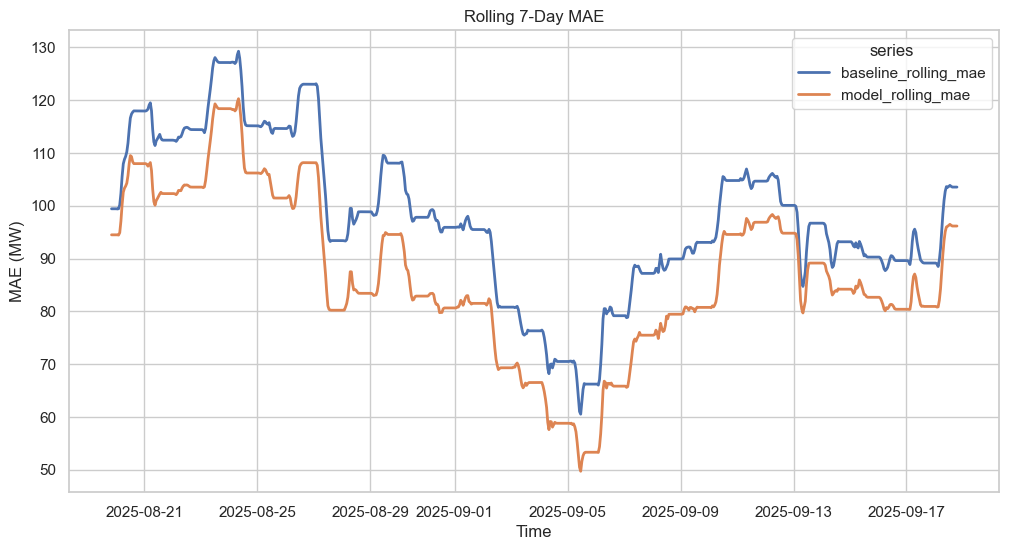

In [72]:
rolling_melt = recent_window.melt(
    id_vars="time_local",
    value_vars=["baseline_rolling_mae", "model_rolling_mae"],
    var_name="series",
    value_name="mae_mw",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=rolling_melt, x="time_local", y="mae_mw", hue="series", linewidth=2, ax=ax)
ax.set_title("Rolling 7-Day MAE")
ax.set_xlabel("Time")
ax.set_ylabel("MAE (MW)")

fig.savefig(FIGURES_ROOT / "07_fig_01_rolling_mae.png", dpi=150, bbox_inches="tight")
plt.show()

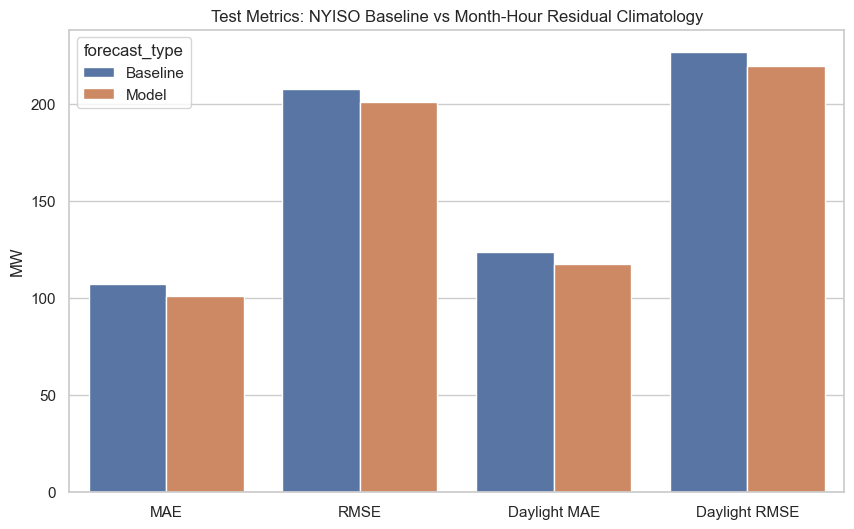

In [73]:
metric_summary = pd.DataFrame({
    "metric": ["MAE", "RMSE", "Daylight MAE", "Daylight RMSE"],
    "Baseline": [
        test_results.loc[test_results["Model"] == "NYISO Baseline", "MAE"].iloc[0],
        test_results.loc[test_results["Model"] == "NYISO Baseline", "RMSE"].iloc[0],
        test_results.loc[test_results["Model"] == "NYISO Baseline", "Daylight_MAE"].iloc[0],
        test_results.loc[test_results["Model"] == "NYISO Baseline", "Daylight_RMSE"].iloc[0],
    ],
    "Model": [
        test_results.loc[test_results["Model"] == best_model, "MAE"].iloc[0],
        test_results.loc[test_results["Model"] == best_model, "RMSE"].iloc[0],
        test_results.loc[test_results["Model"] == best_model, "Daylight_MAE"].iloc[0],
        test_results.loc[test_results["Model"] == best_model, "Daylight_RMSE"].iloc[0],
    ],
}).melt(id_vars="metric", var_name="forecast_type", value_name="value")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=metric_summary, x="metric", y="value", hue="forecast_type", ax=ax)
ax.set_title(f"Test Metrics: NYISO Baseline vs {best_model}")
ax.set_xlabel("")
ax.set_ylabel("MW")
fig.savefig(FIGURES_ROOT / "07_fig_02_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

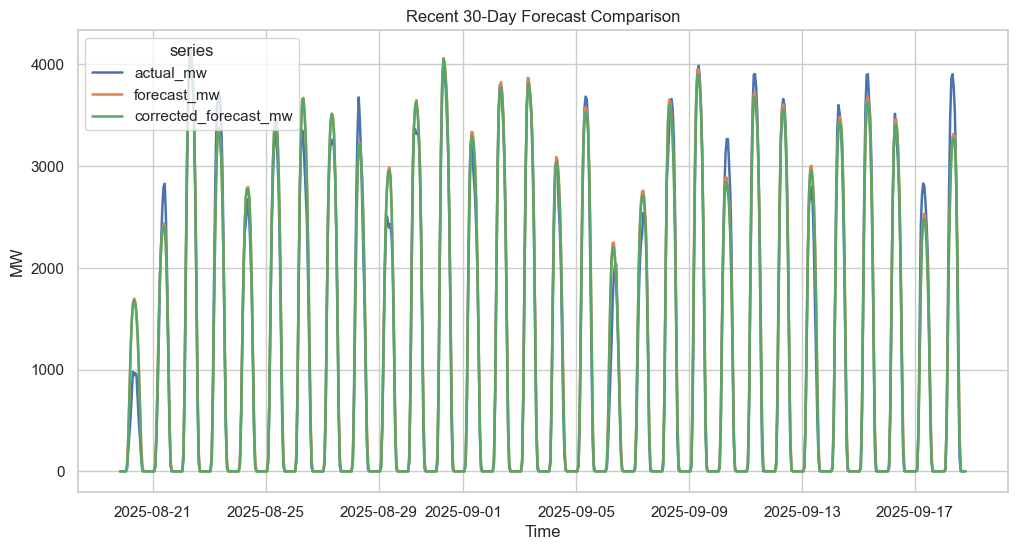

In [74]:
recent_forecast_melt = recent_window.melt(
    id_vars="time_local",
    value_vars=["actual_mw", "forecast_mw", "corrected_forecast_mw"],
    var_name="series",
    value_name="mw",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=recent_forecast_melt, x="time_local", y="mw", hue="series", linewidth=1.8, ax=ax)
ax.set_title("Recent 30-Day Forecast Comparison")
ax.set_xlabel("Time")
ax.set_ylabel("MW")
fig.savefig(FIGURES_ROOT / "07_fig_03_recent_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

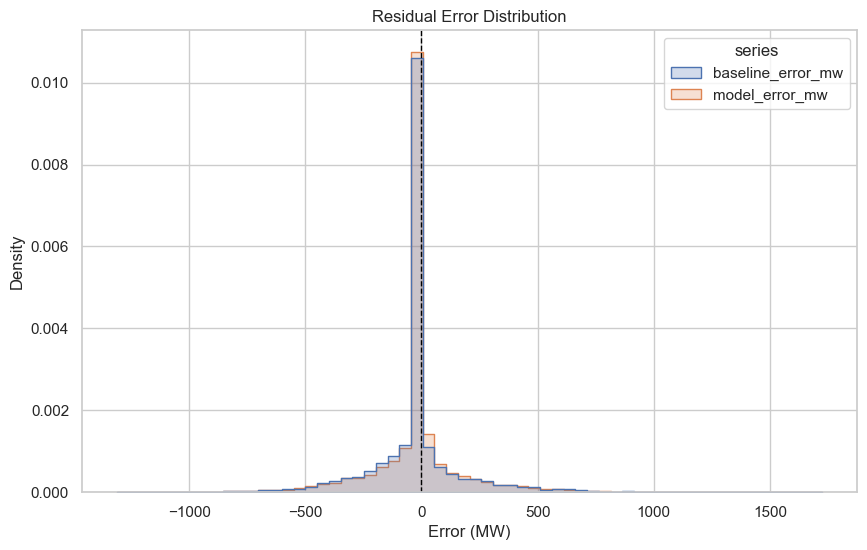

In [75]:
error_dist_melt = analysis_df.melt(
    value_vars=["baseline_error_mw", "model_error_mw"],
    var_name="series",
    value_name="error_mw",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=error_dist_melt,
    x="error_mw",
    hue="series",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    ax=ax,
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residual Error Distribution")
ax.set_xlabel("Error (MW)")
ax.set_ylabel("Density")
fig.savefig(FIGURES_ROOT / "07_fig_04_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

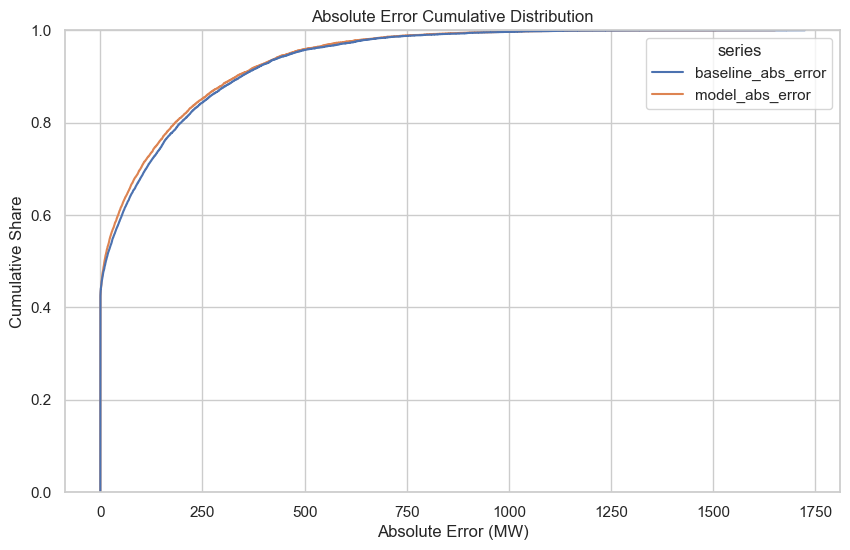

In [76]:
ecdf_melt = analysis_df.melt(
    value_vars=["baseline_abs_error", "model_abs_error"],
    var_name="series",
    value_name="abs_error_mw",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.ecdfplot(data=ecdf_melt, x="abs_error_mw", hue="series", ax=ax)
ax.set_title("Absolute Error Cumulative Distribution")
ax.set_xlabel("Absolute Error (MW)")
ax.set_ylabel("Cumulative Share")

fig.savefig(FIGURES_ROOT / "07_fig_05_error_ecdf.png", dpi=150, bbox_inches="tight")
plt.show()

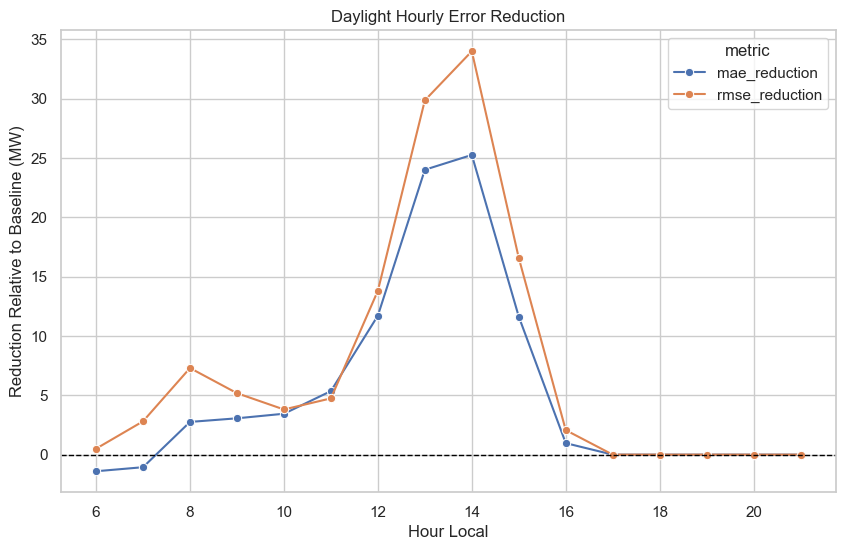

In [77]:

hourly_reduction_melt = hourly_errors[["hour_local", "mae_reduction", "rmse_reduction"]].melt(
    id_vars="hour_local",
    var_name="metric",
    value_name="reduction_mw",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=hourly_reduction_melt, x="hour_local", y="reduction_mw", hue="metric", marker="o", ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Daylight Hourly Error Reduction")
ax.set_xlabel("Hour Local")
ax.set_ylabel("Reduction Relative to Baseline (MW)")

fig.savefig(FIGURES_ROOT / "07_fig_06_hourly_reduction.png", dpi=150, bbox_inches="tight")
plt.show()

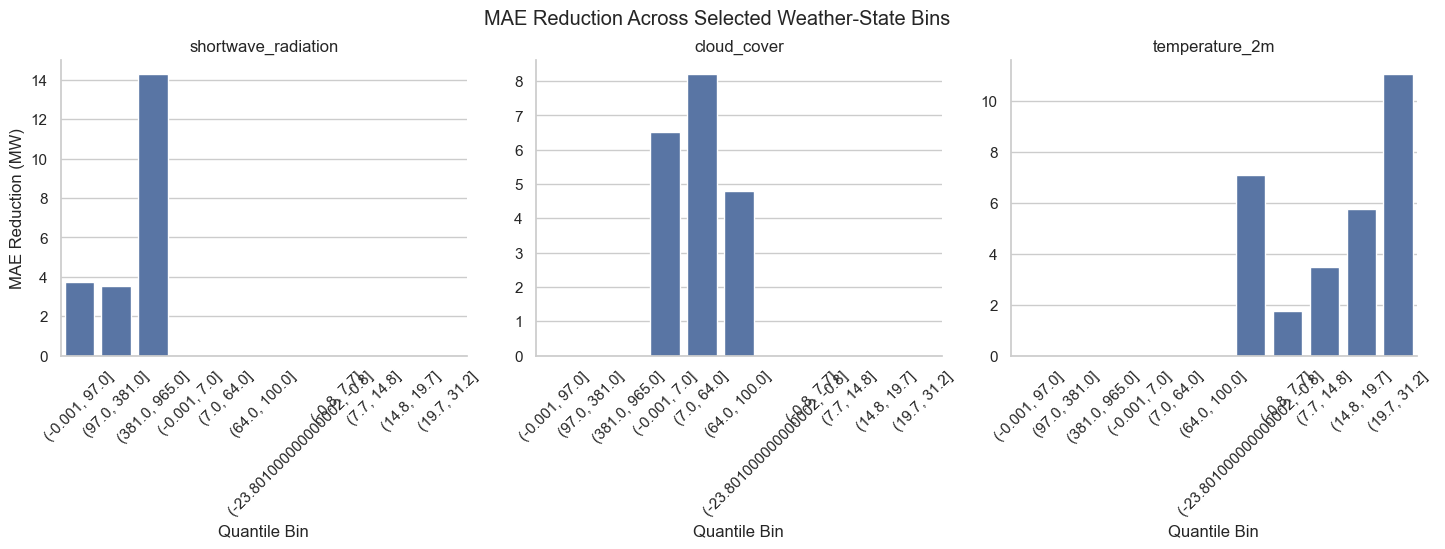

In [78]:
weather_plot = weather_summary.loc[
    weather_summary["variable"].isin(["shortwave_radiation", "cloud_cover", "temperature_2m"])
].copy()

g = sns.catplot(
    data=weather_plot,
    kind="bar",
    x="bin",
    y="mae_reduction",
    col="variable",
    sharey=False,
    height=4,
    aspect=1.2,
)
g.set_axis_labels("Quantile Bin", "MAE Reduction (MW)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.figure.suptitle("MAE Reduction Across Selected Weather-State Bins", y=1.03)

g.figure.savefig(FIGURES_ROOT / "07_fig_07_weather_bins.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion and Next Steps
x